<a href="https://colab.research.google.com/github/shilpacn34-creator/zomato-data-analysis/blob/main/zomatoo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Step1**: **importing libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!wget C:\Users\Shilpa C N\Downloads\Zomato-EDA-Project-main\Zomato-EDA-Project-main\zomato_data.csv

--2026-05-31 13:19:30--  ftp://c/UsersShilpa
           => ‘UsersShilpa’
Resolving c (c)... failed: Name or service not known.
wget: unable to resolve host address ‘c’
--2026-05-31 13:19:30--  http://c/
Resolving c (c)... failed: Name or service not known.
wget: unable to resolve host address ‘c’
--2026-05-31 13:19:30--  http://ndownloadszomato-eda-project-mainzomato-eda-project-mainzomato_data.csv/
Resolving ndownloadszomato-eda-project-mainzomato-eda-project-mainzomato_data.csv (ndownloadszomato-eda-project-mainzomato-eda-project-mainzomato_data.csv)... failed: Name or service not known.
wget: unable to resolve host address ‘ndownloadszomato-eda-project-mainzomato-eda-project-mainzomato_data.csv’


In [ ]:
from google.colab import files
uploaded= files.upload()

Saving zomato_data.csv to zomato_data.csv


In [ ]:
df= pd.read_csv('/content/zomato_data.csv')

# **step2: creating data frame**

In [ ]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [ ]:
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


In [ ]:
df.shape

(148, 7)

In [ ]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

# **step3: converting data type of column-rate**

In [ ]:
def handlerate(values):
  values=str(values).split('/')
  values= values[0]
  return float(values)

df["rate"]= df['rate'].apply(handlerate)
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


# problem 1: What type of restuarant do majority customer order from?

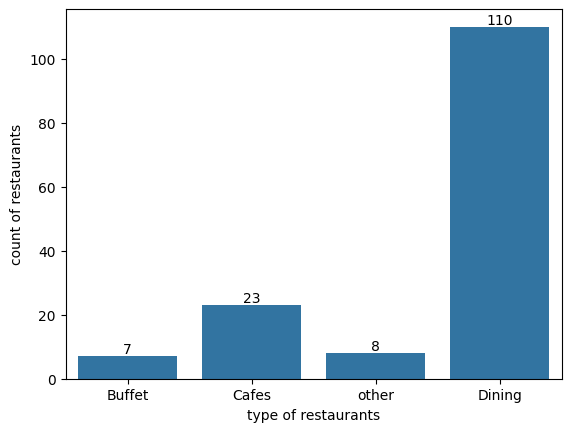

In [ ]:
ax=sns.countplot(x=df['listed_in(type)'])
for bars in ax.containers:
    ax.bar_label(bars)
plt.xlabel('type of restaurants')
plt.ylabel('count of restaurants')
plt.show()


coclusion: "majority of restaurant fall in dining type"

# problem 2: how many votes has each type of restuarant recieves from customer

In [ ]:
grouped_data=df.groupby(['listed_in(type)'])['votes'].sum()
result= pd.DataFrame({'vote':grouped_data})

In [ ]:
result

,vote
listed_in(type),
Buffet,3028
Cafes,6434
Dining,20363
other,9367


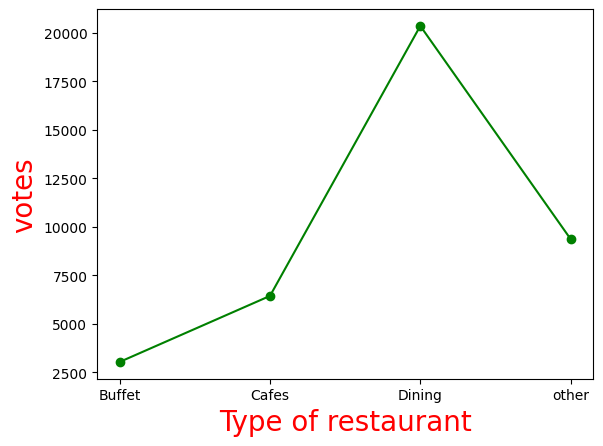

In [ ]:
plt.plot(result,c='green',marker='o')
plt.xlabel('Type of restaurant',c='red',size=20)
plt.ylabel('votes',c='red',size=20)
plt.show()

.conclusion:Dining restaurant has recieved maximum votes

# problem 3: What are the ratings that the majority of restaurants have received?

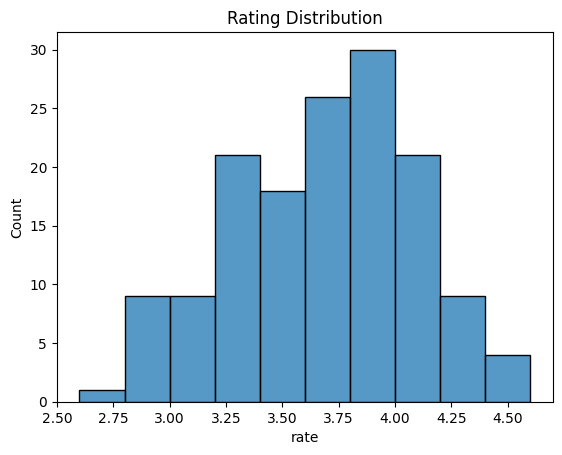

In [ ]:
sns.histplot(df['rate'],bins=10)
plt.title('Rating Distribution')
plt.show()

conclusion: the majority restaurant recieved ratings from 3.5 to 4

# problem 4: Average order spending by couples

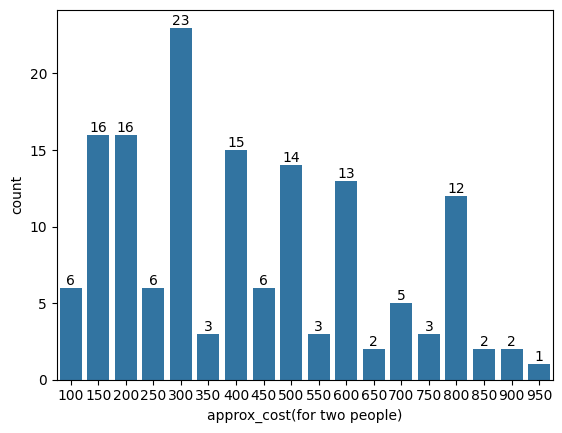

In [ ]:
ax=sns.countplot(x=df['approx_cost(for two people)'])
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()


conclusion: the majority of couple prefer restaurant with an approximate cost of 300 rupees.

# problem 5: which mode received the maximum rating?

In [ ]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


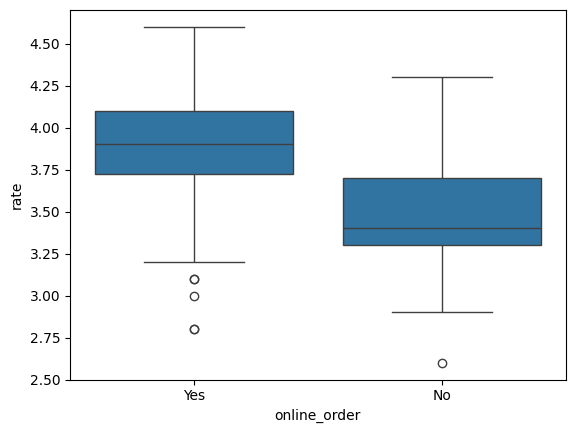

In [ ]:
sns.boxplot(x='online_order', y='rate',data=df)
plt.show()

conclusion: offline order received lower rating in comparision to online orders

# problem 6: which type of restaurant received more offline orders,so that zomoto can provide customer with some good offers

In [ ]:
pivot_table= df.pivot_table(index='listed_in(type)',columns='online_order',aggfunc='size')

In [ ]:
pivot_table

online_order,No,Yes
listed_in(type),,
Buffet,3,4
Cafes,8,15
Dining,77,33
other,2,6


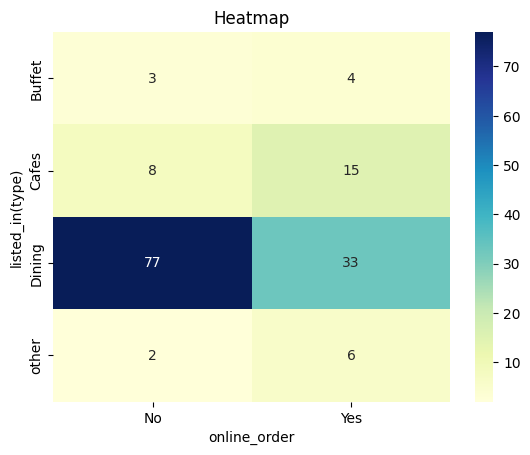

In [ ]:
sns.heatmap(pivot_table,annot=True,cmap='YlGnBu')
plt.title('Heatmap')
plt.show()

conclsion : dining restaurant primarily accept offline order,whereas cafes receives online order.this suggest that clients prefers order in person at restaurant,but prefer online order at cafes.